# Assignment 2: Autonomous Driving (Part 1)

In this assignment, you will prepare training data for learning autonomous driving behavior. The assignment will use simulated data only. For this purpose, we will work with a vehicle-based simulator example from [Gymnasium](https://gymnasium.farama.org/index.html), a framework for developing and evaluating reinforcement learning approaches.

**Important:** You must install [Gymnasium](https://gymnasium.farama.org/index.html) on your system before starting the assignment. Installation can be done using either `uv`, `pip` or `conda` with the following command:

```bash
conda install conda-forge::gymnasium-box2d
# or
uv add gymnasium[box2d]
# or
pip install gymnasium[box2d]
```

Additional installation information is available here: [Gymnasium installation documentation](https://github.com/Farama-Foundation/Gymnasium#installation)

All scripts must be executable on **any** machine with the required libraries installed.\
Assignment solutions may be submitted either as Jupyter notebooks or `.py` files. Visual results may be submitted as part of the notebook, a PDF, or image files.\
When submitting multiple files, create a zip archive that contains any submissions.

![car_racing_simulation](https://gymnasium.farama.org/_images/car_racing.gif)


## Task 1: Car Racing Simulation

In this task, you will use the Car Racing environment from [Gymnasium](https://gymnasium.farama.org/index.html) to generate training data for a later deep learning task.

You will run a simulated car on a race track, with *discrete* actions, and collect image observations from the simulator. At each time step, the simulator returns an image frame of size `96×96` pixels. You must store these image frames together with the control action that was applied at the same time step.

The available control actions include, for example:
- steering left
- steering right
- accelerating
- decelerating
- do nothing

The simulator also provides reward values, but these rewards are not used in this task.


### What you need to do

Generate a training dataset containing **5,000 image frames** by playing in the car racing simulator.

For each frame, store:
1. the image observation returned by the simulator, and
2. the corresponding action label.

The action label is the control action applied when the frame was generated. Represent each label as a **one-hot vector**.

Use the car racing implementation [Gymnasium Box2D Car Racing environment](https://gymnasium.farama.org/environments/box2d/car_racing/) to set up the simulator. In our case we want to collect data by manually controlling the car with our keyboard and the `w`, `a`, `s`, and `d` keys.

Your dataset should contain diverse driving situations and a balanced variety of control actions, since it will later be used to train a deep neural network.
Therefore, it can be helpful to use a key, e.g. the `spacebar` to start and stop recording of frames and thus avoid one long and highly correlated episodes.

*Important*: The scripts should be **self-contained**. Do not apply any augmentations to the data yet.

**Task Output**: The dataset must be stored as a single `.npz` file with the following arrays:

- `images`: image observations of shape `(5000, 96, 96, 3)`, stored as `uint8`
- `labels`: one-hot encoded action labels of shape `(5000, C)`

In addition, a `metadata.json` file describing the action mapping, for example which index corresponds which action, should be generated by your script.

The script to collect and generate the dataset can either be implemented in this notebook or submitted alongside it as a separate `.py` file.

Visualize statistics of your dataset, i.e., the percentage each action is present in the dataset and a histogram of episode lengths.

In [ ]:
import numpy as np
import pandas as pd
import gymnasium as gym
import matplotlib.pyplot as plt
import pygame
from gymnasium.utils.play import play, PlayPlot
import json
from pathlib import Path


TARGET_PER_ACTION = 1000
ENV_ID = "CarRacing-v3"
SCALE = 6
FPS = 30
OUTPUT_NPZ = "data/dataset.npz"
OUTPUT_META = "data/metadata.json"

ACTION_NAMES = {
    0: "do_nothing",
    1: "steer_right",
    2: "steer_left",
    3: "accelerate",
    4: "brake",
}

ACTION_KEYS = {
    0: "no key",
    1: "D",
    2: "A",
    3: "W",
    4: "S",
}

ACTION_ORDER = [1, 2, 3, 4, 0]

def one_hot(action_idx: int, num_classes: int) -> np.ndarray:
    """
    Label every action individually as an vector
    """
    vec = np.zeros(num_classes, dtype=np.uint8) # Create empty vector
    vec[action_idx] = 1 # Set corresponding Bit to 1 (From ACTION_KEYS, e.g. Set second bit to 1 = D)
    return vec # Return One Hot Vector 

# TODO: define key_to_action
def key_to_action(keys) -> int:
    """
    Reading pressed keys and returning corresponding ID-Number from ACTION_KEYS
    """
    if keys[pygame.K_d]:
        return 1
    if keys[pygame.K_a]:
        return 2
    if keys[pygame.K_w]:
        return 3
    if keys[pygame.K_s]:
        return 4
    return 0


def draw_frame(screen, obs):
    """
    Take image from the environment (Observation), Scale shown image and display scaled image
    """
    frame = np.transpose(obs, (1, 0, 2)) # Change x and y axis for correct image display via Pygame (obs from gym are hxwxc, pygame wants wxhxc)
    surface = pygame.surfarray.make_surface(frame) # Change NumPy image to Pygame Surface
    surface = pygame.transform.scale(
        surface, (obs.shape[1] * SCALE, obs.shape[0] * SCALE) # Scale Image just for visual pleasing
    )
    screen.blit(surface, (0, 0)) # Draw image onto active window
    pygame.display.flip() # Refresh display

def all_done(action_counts):
    """
    Check if enough data was collected per action
    """
    return all(count >= TARGET_PER_ACTION for count in action_counts.values()) # True if every action has same amount as action_counts


def main():
    # TODO: display the environment and capture key presses
    pygame.init()
    clock = pygame.time.Clock() # Clock for limiting frame rate

    env = gym.make(ENV_ID, continuous=False, render_mode="rgb_array") # Discrete actions only, rgb_array: every image is saved as NumPy Array
    obs, info = env.reset()

    height, width, _ = obs.shape
    screen = pygame.display.set_mode((width * SCALE, height * SCALE)) # Enlarge displayed image

    images = [] # Images from CarRacing-v3 are 96x96x3 by default
    labels = []

    action_counts = {a: 0 for a in ACTION_NAMES.keys()} # Counter for pressed actions
    episode_lengths = [] 

    recording = False
    running = True
    recorded_in_current_episode = 0

    current_phase = 0
    target_action = ACTION_ORDER[current_phase]

    #User info
    print("SPACE: Recording start/pause")
    print("ESC: Close")
    print(
        f"Start with action: {ACTION_NAMES[target_action]} "
        f"(Key: {ACTION_KEYS[target_action]})"
    )

    while running and not all_done(action_counts): # Loop runs until closed or enough data was collected
        for event in pygame.event.get():
            if event.type == pygame.QUIT: # If window is closed set running False
                running = False

            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_ESCAPE: # If Escape Button was pressed set running False
                    running = False
                # TODO: toggle recording with SPACE
                elif event.key == pygame.K_SPACE: # If Space Bar was pressed change recording to False/True
                    recording = not recording
                    print(f"Recording {'ON' if recording else 'OFF'}")

        keys = pygame.key.get_pressed() # Get keyboard input
        action = key_to_action(keys) # Keyboard input as ingame action

        obs, reward, terminated, truncated, info = env.step(action) # Every step in environment returns observation, terminated/truncated
        # TODO: append image and label when recording=True
        if (
            recording
            and action == target_action
            and action_counts[target_action] < TARGET_PER_ACTION
        ):
            images.append(obs.copy()) # Image append only if target action == pressed key, obs.copy so that image will be saved
            labels.append(one_hot(action, env.action_space.n)) # Label append only if target action == pressed key
            action_counts[target_action] += 1
            recorded_in_current_episode += 1

            remaining = TARGET_PER_ACTION - action_counts[target_action]
            if remaining % 100 == 0 or remaining < 10: # Print message every 100 data, or for every last 10 data 
                print(
                    f"{ACTION_NAMES[target_action]}: "
                    f"{action_counts[target_action]}/{TARGET_PER_ACTION}"
                )
            # TODO: stop after 5000 samples
            if action_counts[target_action] == TARGET_PER_ACTION:
                print(
                    f"Done with {ACTION_NAMES[target_action]} "
                    f"({TARGET_PER_ACTION} Samples)."
                )

                current_phase += 1
                if current_phase < len(ACTION_ORDER):
                    target_action = ACTION_ORDER[current_phase]
                    print(
                        f"Next action: {ACTION_NAMES[target_action]} "
                        f"(Key: {ACTION_KEYS[target_action]})"
                    )
                else:
                    print("All actions successfully recorded.")
        
            
        # Window title with live infos
        pygame.display.set_caption(
            "CarRacing Data Collection | "
            f"Recording: {'ON' if recording else 'OFF'} | "
            f"Target: {ACTION_NAMES[target_action] if current_phase < len(ACTION_ORDER) else 'done'} | "
            f"Needed: "
            f"{action_counts[target_action] if current_phase < len(ACTION_ORDER) else TARGET_PER_ACTION}/"
            f"{TARGET_PER_ACTION}"
        )
        draw_frame(screen, obs)

        if terminated or truncated:
            if recorded_in_current_episode > 0:
                episode_lengths.append(recorded_in_current_episode)
            recorded_in_current_episode = 0
            obs, info = env.reset() # Reset environment if terminated/truncated

        clock.tick(FPS) # Set frame rate to 30 FPS, avoid high CPU usage and avoid too many action inputs in one frame (if 999 FPS Rip action detection) 

    if recorded_in_current_episode > 0:
        episode_lengths.append(recorded_in_current_episode)

    env.close()
    pygame.quit() # Quit environment and pygame

    if len(images) == 0:
        print("No data collected.")
        return

    images = np.stack(images).astype(np.uint8) # Save list of images as a Numpy Array
    labels = np.stack(labels).astype(np.uint8) # Save list of labels as a Numpy Array

    # In case closing the environment before recording all 5000 data, safe collected data
    num_samples = images.shape[0]

    # TODO: save dataset.npz and metadata.json
    np.savez_compressed(OUTPUT_NPZ, images=images, labels=labels)

    metadata = {
        "env_id": ENV_ID,
        "continuous": False,
        "num_samples": int(len(images)),
        "image_shape": list(images.shape),
        "label_shape": list(labels.shape),
        "label_encoding": "one_hot",
        "action_mapping": ACTION_NAMES,
        "action_keys": ACTION_KEYS,
        "action_order": ACTION_ORDER,
        "target_per_action": TARGET_PER_ACTION,
        "action_counts": action_counts,
        "episode_lengths": episode_lengths,
        "recording_toggle_key": "SPACE",
        "collection_mode": "sequential_actions_manual",
    }

    with open(OUTPUT_META, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2) # Open saving path for Metadata.json, write all collected metadata with indent (2 spaces)

    print(f"Gespeichert: {OUTPUT_NPZ}")
    print(f"Gespeichert: {OUTPUT_META}")
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print("Action counts:", action_counts)

    # Plot statistics
    counts = np.array([action_counts[i] for i in range(len(ACTION_NAMES))])
    percentages = counts / counts.sum() * 100

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.bar([ACTION_NAMES[i] for i in range(len(ACTION_NAMES))], percentages)
    plt.ylabel("Percentage [%]")
    plt.title("Action Distribution")
    plt.xticks(rotation=30)

    plt.subplot(1, 2, 2)
    plt.hist(episode_lengths, bins=min(20, max(1, len(episode_lengths))))
    plt.xlabel("Recorded frames per episode")
    plt.ylabel("Count")
    plt.title("Episode Length Histogram")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

SPACE: Aufnahme starten/pausieren
ESC: Beenden
Starte mit Aktion: steer_right (Taste: D)
Recording ON
steer_right: 100/1000
steer_right: 200/1000
steer_right: 300/1000
steer_right: 400/1000
steer_right: 500/1000
steer_right: 600/1000
steer_right: 700/1000
steer_right: 800/1000
steer_right: 900/1000
steer_right: 991/1000
steer_right: 992/1000
steer_right: 993/1000
steer_right: 994/1000
steer_right: 995/1000
steer_right: 996/1000
steer_right: 997/1000
steer_right: 998/1000
steer_right: 999/1000
steer_right: 1000/1000
Fertig mit steer_right (1000 Samples).
Nächste Aktion: steer_left (Taste: A)
steer_left: 100/1000
steer_left: 200/1000
steer_left: 300/1000
steer_left: 400/1000
steer_left: 500/1000
steer_left: 600/1000
steer_left: 700/1000
steer_left: 800/1000
steer_left: 900/1000
steer_left: 991/1000
steer_left: 992/1000
steer_left: 993/1000
steer_left: 994/1000
steer_left: 995/1000
steer_left: 996/1000
steer_left: 997/1000
steer_left: 998/1000
steer_left: 999/1000
steer_left: 1000/1000
Fe

In [7]:
from matplotlib import pyplot as plt

# TODO: load your dataset in numpy
data = np.load("data/dataset.npz")
images = data["images"]
labels = data["labels"]

assert images.shape == (5000, 96, 96, 3)
assert images.dtype == np.uint8
assert labels.shape == (5000, 5)
assert np.all(labels.sum(axis=1) == 1), "There should be exactly one action per frame."

# TODO: plot dataset metrics
action_names = [
    "do_nothing",
    "steer_left",
    "steer_right",
    "accelerate",
    "brake",
]

action_counts = labels.sum(axis=0)
action_percentages = action_counts / len(labels) * 100

plt.figure(figsize=(8, 4))
plt.bar(action_names, action_percentages)
plt.ylabel("Percentage [%]")
plt.title("Action distribution in dataset")
plt.xticks(rotation=30)
plt.show()

#---------------------------- Example Images ------------------------------------
plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(action_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()
#--------------------------------------------------------------------------------

#-------------------------- Histogram of episode lengths -------------------------
with open("data/metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

if "episode_lengths" in metadata:
    episode_lengths = metadata["episode_lengths"]

    plt.figure(figsize=(6, 4))
    plt.hist(episode_lengths, bins=min(20, len(episode_lengths)))
    plt.xlabel("Recorded frames per episode")
    plt.ylabel("Count")
    plt.title("Histogram of episode lengths")
    plt.show()
else:
    print(
        "No 'episode_lengths' found in metadata.json. "
        "Histogram cannot be plotted from images/labels alone."
    )
#--------------------------------------------------------------------------------

## Task 2: Data Preparation for PyTorch

In this task, you will prepare the dataset collected in Task 1 for training a neural network in PyTorch.

First, load the collected car racing dataset and convert it into a PyTorch-compatible format. Then, implement a custom dataset and data loader, similar to assignment 1, that return mini-batches of image frames and their corresponding one-hot action labels.

Before using your data it is always good to have a look at it first. Visualize a small subset of the dataset, for example the first 30 image-label pairs, to verify that the data has been loaded correctly.

You must also implement data augmentation directly in the data loading pipeline. The following augmentations should be supported:

- horizontal flipping
- gaussian noise
- changing the road color from gray to brown

Each augmentation must be optional, so that it can be turned on or off independently.
*Note*: Think about how your labels might need to change with the augmentations.

### What you need to do

Implement a PyTorch data loading pipeline that:

1. loads the dataset generated in Task 1,
2. returns image frames and corresponding one-hot action labels,
3. visualizes a subset of the loaded data, such as the first 30 samples,
4. applies data augmentation dynamically during mini-batch loading, and
5. allows each augmentation to be enabled or disabled independently.

**Task Output**: The implemented data pipeline in the code cell below.

### Important Notes

All scripts must be self-contained and executable on **any** machine with the required libraries installed.

Data augmentation must be applied dynamically when a mini-batch is loaded. *Do not* create and store augmented copies of the dataset in advance.

Batch images: torch.Size([64, 3, 96, 96])
Batch labels: torch.Size([64, 5])


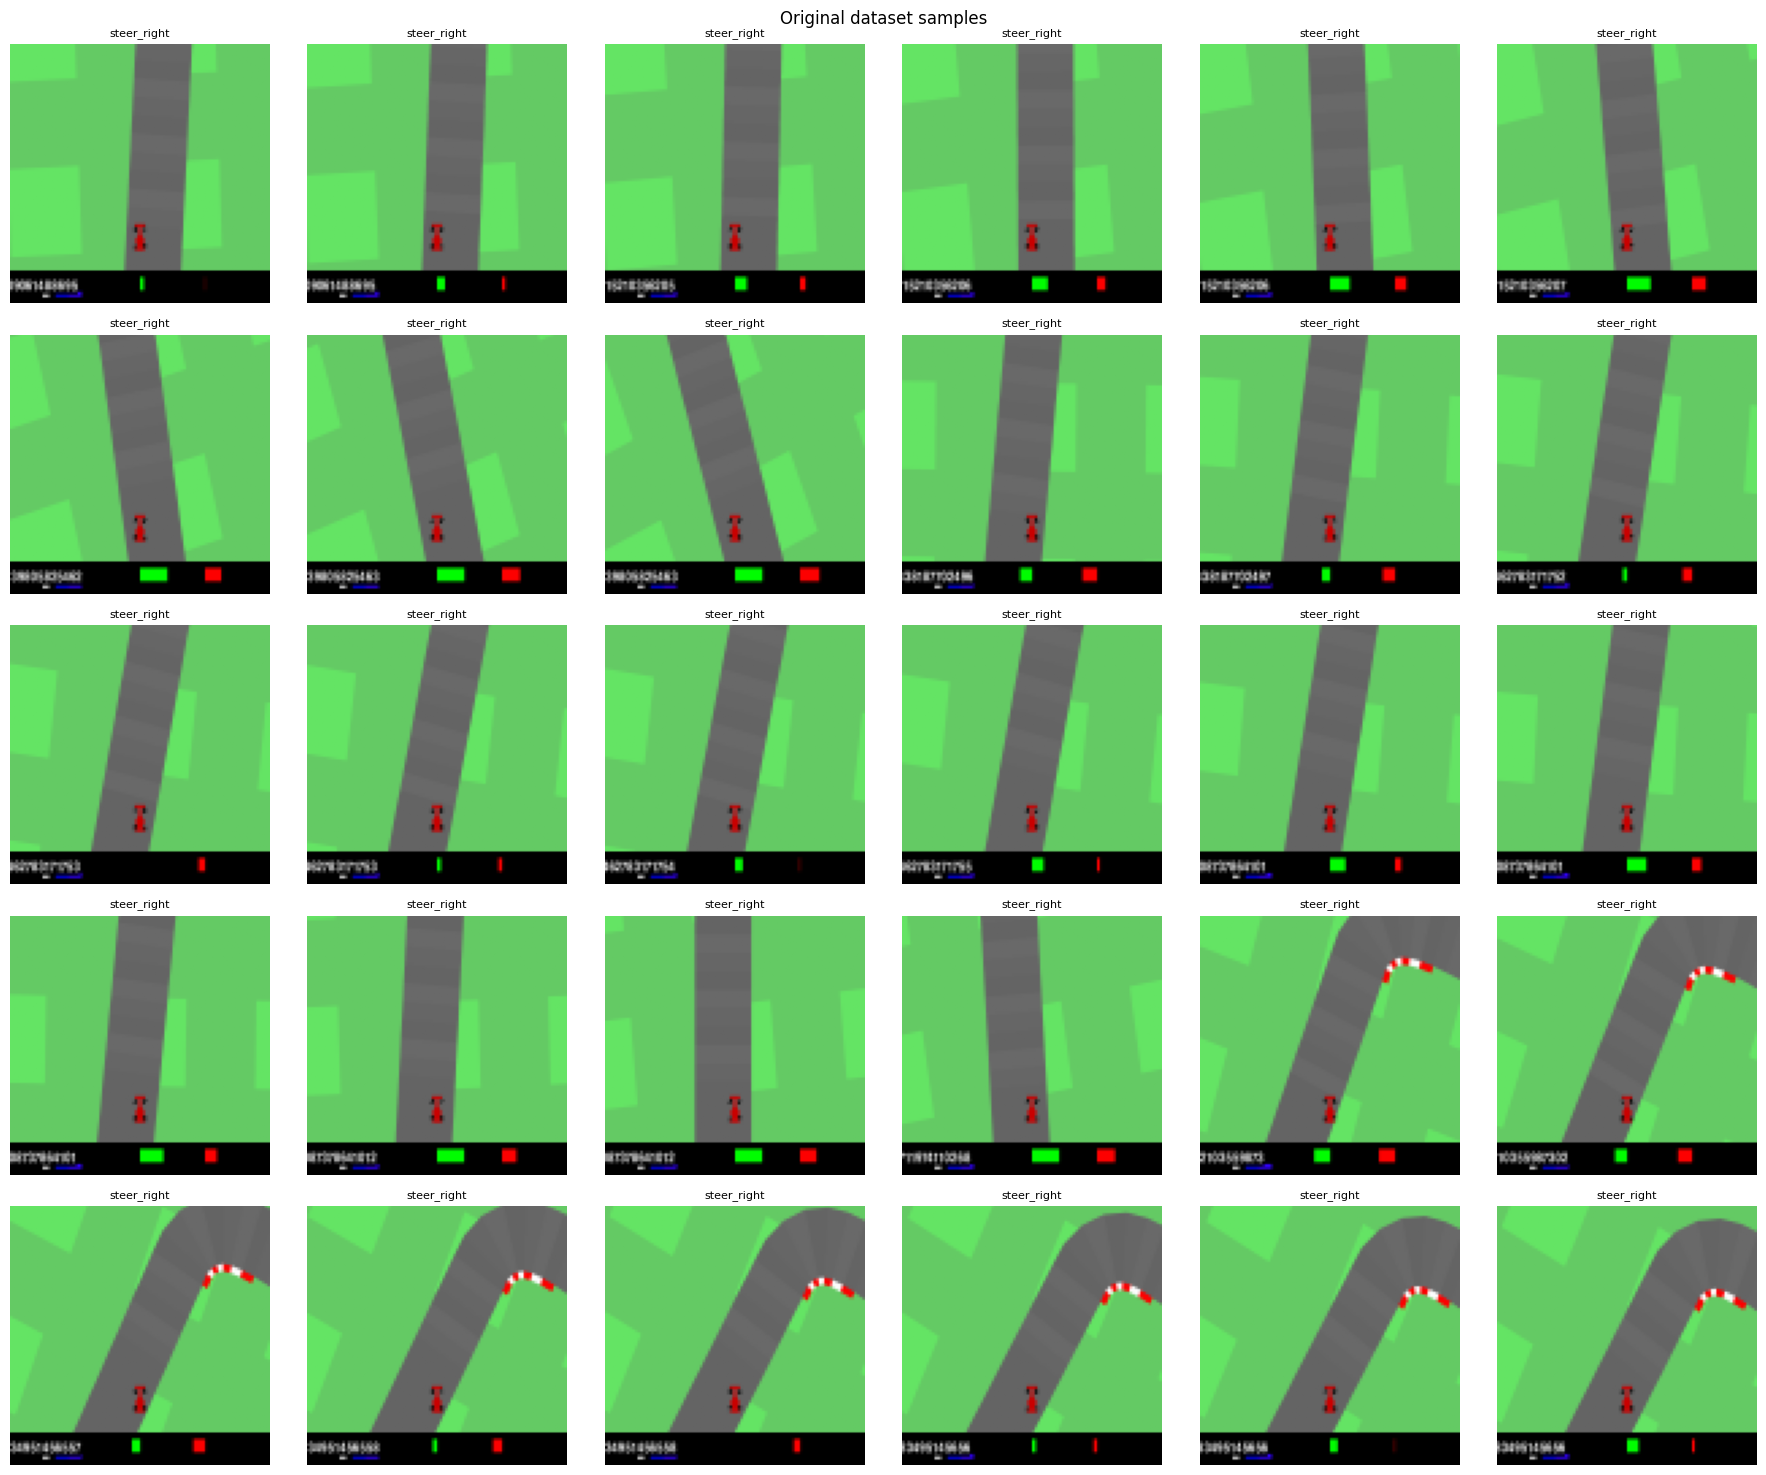

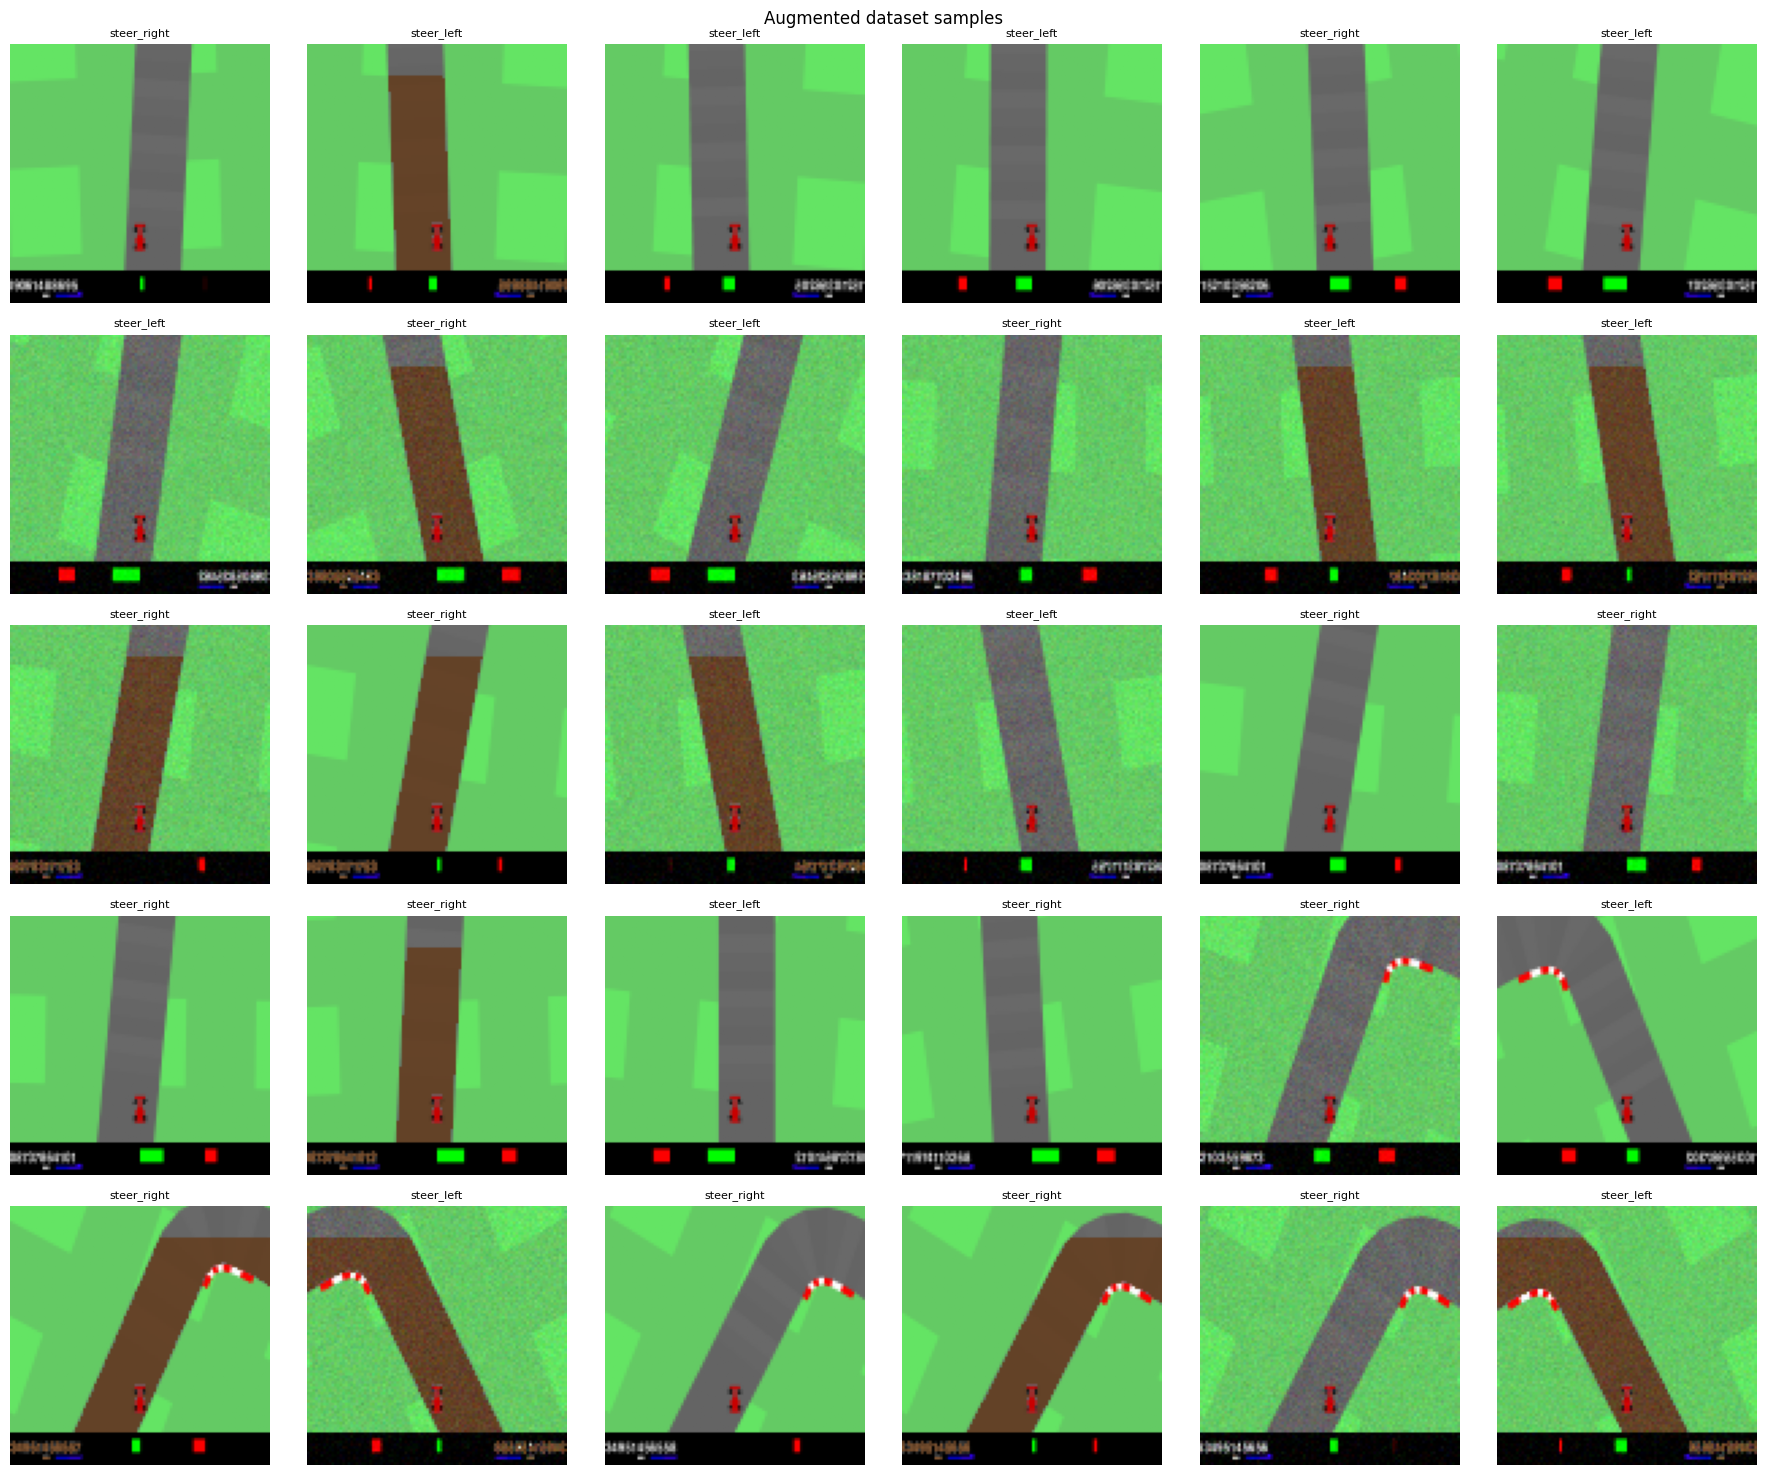

Action Labels in Batch: tensor([2, 1, 2, 4, 1, 0, 2, 1, 3, 0, 0, 4, 4, 3, 3, 4, 0, 0, 0, 0, 0, 0, 4, 4,
        3, 4, 3, 4, 2, 4, 1, 4, 0, 2, 4, 2, 0, 3, 1, 0, 4, 4, 4, 1, 0, 0, 4, 2,
        4, 1, 4, 3, 0, 2, 4, 3, 0, 3, 2, 4, 4, 3, 3, 0])
Actions Sum in Batch: tensor([17,  7,  9, 11, 20])


In [ ]:
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt
import json
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt



# TODO: Implement the CarRacingDataset class to load and preprocess the CarRacing dataset from task 1
class CarRacingDataset(Dataset):

    def __init__(
        self,
        data_dir,
        horizontal_flip=False,
        flip_prob=0.5,
        gaussian_noise=False,
        noise_prob=0.5,
        noise_std=0.03,
        brown_road=False,
        brown_prob=0.5,
    ):
        path = Path(data_dir)

        # Erlaubt sowohl "dataset.npz" als auch einen Ordner
        if path.is_dir(): # For directories
            data_path = path / "dataset.npz"
            meta_path = path / "metadata.json"
        else: # For explicit link to data
            data_path = path 
            meta_path = path.with_name("metadata.json")

        with np.load(data_path) as data:
            self.images = data["images"].copy() # Load images without changing dataset
            self.labels = data["labels"].astype(np.float32).copy() # Preperation for PyTorch

        assert self.images.shape == (5000, 96, 96, 3)
        assert self.images.dtype == np.uint8
        assert self.labels.shape == (5000, 5)
        assert np.all(self.labels.sum(axis=1) == 1), ( # Check whether one hot vectors are really one hot
            "There should be exactly one action per frame."
        )

        self.horizontal_flip = horizontal_flip
        self.flip_prob = flip_prob
        self.gaussian_noise = gaussian_noise
        self.noise_prob = noise_prob
        self.noise_std = noise_std
        self.brown_road = brown_road
        self.brown_prob = brown_prob

        # Load action names from metadata.json
        if meta_path.exists():
            with open(meta_path, "r", encoding="utf-8") as f: # Read mode
                metadata = json.load(f)

            action_mapping = metadata.get("action_mapping", None)
            if isinstance(action_mapping, dict):
                parsed_names = []
                for i in range(5):
                    if str(i) in action_mapping:
                        parsed_names.append(action_mapping[str(i)]) # json saves indices/keys as string
                    elif i in action_mapping: # If no keys can be found
                        parsed_names.append(action_mapping[i])
                    else:
                        print("Error loading Action names from metadata.json")
                self.action_names = parsed_names

    def __len__(self):
        return len(self.images)
    
    @staticmethod
    def _flip_label_left_right(label): # Needed wenn image will be flipped horizontally
        """
        Change one hot labels for:
        1 = steer_left
        2 = steer_right
        """
        label = label.copy()
        label[[1, 2]] = label[[2, 1]]
        return label
    
    @staticmethod
    def _change_road_to_brown(image):
        """
        Simple heuristics:
        Gray Street pixels will be colored in brown
        """
        img = image.astype(np.float32).copy() # Change to float32 to avoid overflow

        r = img[..., 0]
        g = img[..., 1]
        b = img[..., 2]

        # Gray pixels: Channels similiar and mean intensity
        gray_mask = (
            (np.abs(r - g) < 15)
            & (np.abs(g - b) < 15)
            & (r > 60)
            & (r < 200)
        )

        # Don't change HUD
        gray_mask[:12, :] = False # First 12 rows should not be changed

        # Calculate mean brightness of pixels
        brightness = img.mean(axis=-1, keepdims=True) / 255.0
        brown_base = np.array([150.0, 100.0, 60.0], dtype=np.float32).reshape(
            1, 1, 3
        )
        #Apply brown colour without changing brightness of pixels
        brown_img = np.clip((0.45 + 0.55 * brightness) * brown_base, 0, 255)

        img[gray_mask] = brown_img[gray_mask]
        return img.astype(np.uint8)

    def __getitem__(self, idx):
        image = self.images[idx].copy()
        label = self.labels[idx].copy()

        # 1) Horizontal flip
        if self.horizontal_flip and np.random.rand() < self.flip_prob:
            image = np.ascontiguousarray(np.fliplr(image)) # NumPy.FlipLeftRight(image), np.ascontiguousarray preserves array from changes
            label = self._flip_label_left_right(label) # Flip label 

        # 2) Change street color
        if self.brown_road and np.random.rand() < self.brown_prob:
            image = self._change_road_to_brown(image)

        # Change to float float [0, 1] 
        image = image.astype(np.float32) / 255.0

        # 3) Gaussian noise
        if self.gaussian_noise and np.random.rand() < self.noise_prob:
            noise = np.random.normal(
                loc=0.0,
                scale=self.noise_std,
                size=image.shape,
            ).astype(np.float32)
            image = np.clip(image + noise, 0.0, 1.0)

        # HxWxC -> CxHxW for PyTorch
        image = torch.from_numpy(np.transpose(image, (2, 0, 1))).float()
        label = torch.from_numpy(label).float()

        return image, label
    

def visualize_samples(dataset, n=30, title="Dataset samples"):
    n = min(n, len(dataset))
    cols = 6
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i in range(n):
        image, label = dataset[i]
        image_np = image.permute(1, 2, 0).numpy()
        action_idx = int(torch.argmax(label).item())
        action_name = dataset.action_names[action_idx]

        axes[i].imshow(image_np)
        axes[i].set_title(action_name, fontsize=8)
        axes[i].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# TODO: Create a DataLoader
dataset = CarRacingDataset( # Dataset without augmentation
    data_dir="data/dataset.npz",
    horizontal_flip=False,
    gaussian_noise=False,
    brown_road=False,
)

loader = DataLoader( # Dataloader
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

# Load minibatch for testing
batch_images, batch_labels = next(iter(loader))
print("Batch images:", batch_images.shape)  # (B, 3, 96, 96)
print("Batch labels:", batch_labels.shape)  # (B, 5)

# TODO: Visualize some samples from the dataset
visualize_samples(dataset, n=30, title="Original dataset samples")

# TODO: Add augmentation techniques for the CarRacing dataset

augmented_dataset = CarRacingDataset( # Dataset with augmentation
    data_dir="data/dataset.npz",
    horizontal_flip=True,
    flip_prob=0.5,
    gaussian_noise=True,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=True,
    brown_prob=0.5,
)
augmented_loader = DataLoader( # Dataloader
    augmented_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)


# TODO: Visualize some augmented samples from the dataset
visualize_samples(augmented_dataset, n=30, title="Augmented dataset samples")

images, labels = next(iter(loader))
actions = torch.argmax(labels, dim=1)
print(f"Action Labels in Batch: {actions}")
print(f"Actions Sum in Batch: {torch.bincount(actions, minlength=5)}")

## Task 3: Imitation Learning

In this task, you will study the basic idea of imitation learning. This concept will be used in the next assignment to train a driving model from the data collected here.

Read the provided references and answer the questions below **in your own words**.

### What you need to do

Prepare a short written summary that answers the following questions:

1. What is imitation learning?
2. How does imitation learning differ from reinforcement learning?
3. How does imitation learning compare to Guided Policy Search?
4. What are the main advantages of imitation learning?
5. What are the main disadvantages or limitations of imitation learning?

Your answers should be concise but complete. The goal is not to reproduce the papers in detail, but to show that you understand the basic concept and how it relates to autonomous driving.

We might ask some questions during the session.

*Task Output*: Submit your answers in this markdown cells below.

### References

- [End-to-end Driving via Conditional Imitation Learning](https://arxiv.org/abs/1710.02410)
- [Guided Policy Search](https://graphics.stanford.edu/projects/gpspaper/gps_full.pdf)

### Task Output

1. What is imitation learning?\
**Answer**:


2. How does imitation learning differ from reinforcement learning?\
**Answer**:

3. How does imitation learning compare to Guided Policy Search?\
**Answer**:

4. What are the main advantages of imitation learning?\
**Answer**:


5. What are the main disadvantages or limitations of imitation learning?\
**Answer**: